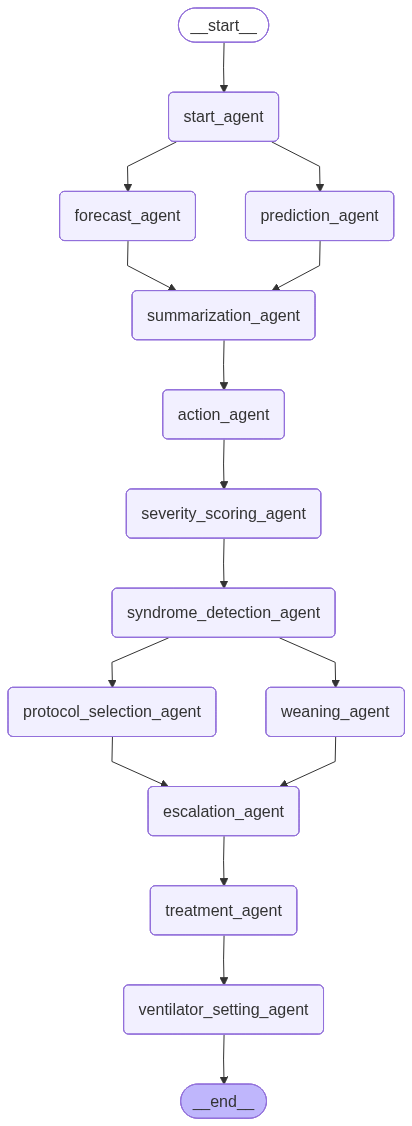

In [ ]:
from langchain_ollama import ChatOllama

# Create BioMistral LLM
llm = ChatOllama(
    model="hf.co/BioMistral/BioMistral-7B-GGUF:latest"
)

from pydantic import BaseModel, Field
from typing import Optional


class ForecastSt(BaseModel):
    heart_rate: float
    sbp: float
    dbp: float
    mbp: float
    temperature: float
    sbp_ni: float
    dbp_ni: float
    mbp_ni: float
    spO2: float
    glucose: float
    sofa_24_hours: float
    model_config = {
        "extra": "forbid"
    }


class ForecastOutput(BaseModel):
    forecasted_vitals: ForecastSt
    model_config = {
        "extra": "forbid"
    }


class OutcomesSt(BaseModel):
    discharge_outcome: bool
    icuouttime_outcome: bool
    death_outcome: bool
    sepsis_outcome: bool
    los_outcome: float
    model_config = {
        "extra": "forbid"
    }


class OutcomeOutput(BaseModel):
    outcome: OutcomesSt
    model_config = {
        "extra": "forbid"
    }


import operator
from typing import Annotated, Dict, Optional
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage


class OverallState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

    # =========================
    # Static patient data (single, does not change over time window)
    # =========================
    original_static: Dict[str, str]

    # =========================
    # CURRENT data (most recent reading — T=0)
    # =========================
    original_vitals: Dict[str, float]
    original_labs: Dict[str, float]
    original_gcs: Dict[str, float]
    original_ventilator: Dict[str, float]
    original_interventions: Dict[str, int]
    original_outcomes: Dict[str, float]

    # =========================
    # PRIOR data (reading from 1 hour ago — T=-1h)
    # =========================
    prior_vitals: Dict[str, float]
    prior_labs: Dict[str, float]
    prior_gcs: Dict[str, float]
    prior_ventilator: Dict[str, float]
    prior_interventions: Dict[str, int]

    # ---------------------------
    # Previous agent outputs (from last graph run)
    # --------------------------
    previous_forecasted_vitals: Optional[ForecastSt]
    previous_clinical_summary: Optional[str]
    previous_outcomes: Optional[OutcomesSt]

    # =========================
    # LLM structured outputs
    # =========================
    forecasted_vitals: Optional[ForecastSt]
    clinical_summary: Optional[str]
    outcomes: Optional[OutcomesSt]
    recommended_ventilator_changes: Optional[Dict[str, float]]
    recommended_interventions: Optional[Dict[str, int]]
    improvement_detected: Optional[bool]
    severity_scores: Optional[Dict[str, float]]
    detected_syndromes: Optional[Dict[str, bool]]
    selected_protocols: Optional[Dict[str, str]]
    escalation_decision: Optional[Dict[str, int]]
    weaning_recommendation: Optional[Dict[str, int]]


outcome_model = llm.with_structured_output(OutcomeOutput)
forecast_model = llm.with_structured_output(ForecastOutput)

from typing import Literal
from langchain_core.messages import SystemMessage, HumanMessage


def start_agent(state: OverallState):
    return {}


def forecast_agent(state: OverallState):

    previous_forecast = state.get("forecasted_vitals")

    system_prompt = SystemMessage(
        content=(
            "You are an ICU physiological forecasting agent. "
            "You are given TWO snapshots of patient data separated by 1 hour: "
            "'Prior (T-1h)' is the reading from 1 hour ago, and 'Current (T=0)' is the most recent reading. "
            "Use the trend between these two time points to predict the patient's future vital signs "
            "for the next monitoring interval. "
            "Forecast realistic ICU physiological values. "
            "Do not hallucinate parameters. Only use defined vital fields."
        )
    )

    human_prompt = HumanMessage(
        content=f"""
        Static variables: {state['original_static']}

        --- Prior vitals (T-1h) ---
        Vitals:       {state['prior_vitals']}
        Labs:         {state['prior_labs']}
        GCS:          {state['prior_gcs']}
        Ventilator:   {state['prior_ventilator']}
        Interventions:{state['prior_interventions']}

        --- Current vitals (T=0) ---
        Vitals:       {state['original_vitals']}
        Labs:         {state['original_labs']}
        GCS:          {state['original_gcs']}
        Ventilator:   {state['original_ventilator']}
        Interventions:{state['original_interventions']}
        """
    )

    structured = forecast_model.invoke([system_prompt, human_prompt])

    return {
        "previous_forecasted_vitals": previous_forecast,
        "forecasted_vitals": structured.forecasted_vitals,
    }


def prediction_agent(state: OverallState):

    previous_outcomes = state.get("outcomes")

    system_prompt = SystemMessage(
        content=(
            "You are an ICU clinical prediction agent. "
            "You are given TWO snapshots of patient data separated by 1 hour: "
            "'Prior (T-1h)' is the reading from 1 hour ago, and 'Current (T=0)' is the most recent reading. "
            "Analyze the trend between the two time points along with current vitals, labs, "
            "ventilator settings, and interventions. "
            "Predict the following outcomes:\n"
            "- discharge_outcome (True if likely discharge)\n"
            "- icuouttime_outcome (True if ICU exit likely)\n"
            "- death_outcome (True if mortality risk high)\n"
            "- sepsis_outcome (True if sepsis likely)\n"
            "- los_outcome (predicted ICU length of stay in hours)\n"
            "Be medically realistic and conservative."
        )
    )

    human_prompt = HumanMessage(
        content=f"""
        Static variables: {state['original_static']}

        --- Prior data (T-1h) ---
        Vitals:       {state['prior_vitals']}
        Labs:         {state['prior_labs']}
        GCS:          {state['prior_gcs']}
        Ventilator:   {state['prior_ventilator']}
        Interventions:{state['prior_interventions']}

        --- Current data (T=0) ---
        Vitals:       {state['original_vitals']}
        Labs:         {state['original_labs']}
        GCS:          {state['original_gcs']}
        Ventilator:   {state['original_ventilator']}
        Interventions:{state['original_interventions']}
        """
    )

    structured = outcome_model.invoke([system_prompt, human_prompt])

    return {
        "previous_outcomes": previous_outcomes,
        "outcomes": structured.outcome,
    }


def summarization_agent(state: OverallState):

    previous_summary = state.get("clinical_summary")
    forecasted_vitals = state.get("forecasted_vitals")
    outcomes = state.get("outcomes")

    fv = forecasted_vitals.model_dump() if forecasted_vitals else {}
    oc = outcomes

    system_prompt = SystemMessage(content=(
        "You are an ICU physician. Write a short clinical summary with exactly four paragraphs:\n"
        "Paragraph 1 - TREND: compare T-1h vs current vitals and state if the patient is improving or deteriorating.\n"
        "Paragraph 2 - CURRENT STATUS: describe the patient's condition right now based on vitals, labs, GCS, and ventilator.\n"
        "Paragraph 3 - FORECAST: describe what the predicted vitals suggest will happen next.\n"
        "Paragraph 4 - OUTCOMES: state each predicted outcome and what it means clinically, flagging any high-risk findings.\n"
        "Be brief and use plain medical language. No bullet points, no extra headings."
    ))

    human_prompt = HumanMessage(content=(
        f"Patient: {state['original_static'].get('anchor_age','?')}yo "
        f"{state['original_static'].get('gender','?')}, "
        f"unit: {state['original_static'].get('first_careunit','?')}.\n\n"

        f"PRIOR VITALS (T-1h): HR={state['prior_vitals'].get('heart_rate')}, "
        f"SBP={state['prior_vitals'].get('sbp')}, MBP={state['prior_vitals'].get('mbp')}, "
        f"SpO2={state['prior_vitals'].get('spO2')}%, Temp={state['prior_vitals'].get('temperature')}C. "
        f"pH={state['prior_labs'].get('pH')}, pCO2={state['prior_labs'].get('pCO2')}, "
        f"GCS={state['prior_gcs'].get('gcs')}, SOFA={state['prior_gcs'].get('sofa_24_hours')}.\n"

        f"CURRENT VITALS (T=0): HR={state['original_vitals'].get('heart_rate')}, "
        f"SBP={state['original_vitals'].get('sbp')}, MBP={state['original_vitals'].get('mbp')}, "
        f"SpO2={state['original_vitals'].get('spO2')}%, Temp={state['original_vitals'].get('temperature')}C. "
        f"pH={state['original_labs'].get('pH')}, pCO2={state['original_labs'].get('pCO2')}, "
        f"pO2={state['original_labs'].get('pO2')}, GCS={state['original_gcs'].get('gcs')}, "
        f"SOFA={state['original_gcs'].get('sofa_24_hours')}. "
        f"FiO2={state['original_ventilator'].get('set_fio21')}%, "
        f"PEEP={state['original_ventilator'].get('set_peep1')}, "
        f"RR={state['original_ventilator'].get('set_rr1')}. "
        f"invasive={state['original_interventions'].get('invasive')}, "
        f"NIV={state['original_interventions'].get('noninvasive')}, "
        f"vasopressor={state['original_interventions'].get('vasopressor')}.\n\n"

        f"FORECASTED VITALS: HR={fv.get('heart_rate','?')}, SBP={fv.get('sbp','?')}, "
        f"MBP={fv.get('mbp','?')}, SpO2={fv.get('spO2','?')}%, "
        f"SOFA={fv.get('sofa_24_hours','?')}.\n\n"

        f"PREDICTED OUTCOMES: discharge={oc.discharge_outcome if oc else 'N/A'}, "
        f"ICU_exit={oc.icuouttime_outcome if oc else 'N/A'}, "
        f"death_risk={oc.death_outcome if oc else 'N/A'}, "
        f"sepsis={oc.sepsis_outcome if oc else 'N/A'}, "
        f"LOS={round(oc.los_outcome, 1) if oc else 'N/A'} hrs.\n\n"

        "Write the four-paragraph clinical summary now."
    ))

    response = llm.invoke([system_prompt, human_prompt])

    return {
        "previous_clinical_summary": previous_summary,
        "clinical_summary": response.content
    }


# ─────────────────────────────────────────────────────────────────────────────
# All agents below are rule-based and use forecasted_vitals / original_*
# (current snapshot only). No changes needed for the 2-hour window here.
# ─────────────────────────────────────────────────────────────────────────────

def severity_scoring_agent(state: OverallState):

    forecast = state.get("forecasted_vitals")
    labs = state.get("original_labs")
    gcs = state.get("original_gcs")
    vent = state.get("original_ventilator")

    if forecast is None:
        return {}

    scores = {}

    if forecast.sbp > 0:
        scores["shock_index"] = forecast.heart_rate / forecast.sbp
    else:
        scores["shock_index"] = 0

    scores["hypotension"] = forecast.mbp < 65
    scores["hypoxia"] = forecast.spO2 < 92
    scores["severe_hypoxia"] = forecast.spO2 < 88

    if labs:
        scores["acidosis"] = labs["pH"] < 7.35
        scores["hypercapnia"] = labs["pCO2"] > 45
        scores["hypoxemia_lab"] = labs["pO2"] < 80
    else:
        scores["acidosis"] = False
        scores["hypercapnia"] = False
        scores["hypoxemia_lab"] = False

    if gcs:
        scores["neurological_impairment"] = gcs["gcs"] < 13
    else:
        scores["neurological_impairment"] = False

    if vent:
        scores["high_fio2"] = vent["set_fio21"] > 40
        scores["high_peep"] = vent["set_peep1"] > 8
    else:
        scores["high_fio2"] = False
        scores["high_peep"] = False

    return {"severity_scores": scores}


def syndrome_detection_agent(state: OverallState):

    scores = state.get("severity_scores")
    outcomes = state.get("outcomes")

    if scores is None:
        return {}

    syndromes = {}

    syndromes["respiratory_failure"] = (
        scores["hypoxia"]
        or scores["hypoxemia_lab"]
        or scores["high_fio2"]
        or scores["hypercapnia"]
    )

    syndromes["severe_respiratory_failure"] = (
        scores["severe_hypoxia"]
        or (scores["hypoxia"] and scores["hypercapnia"])
    )

    syndromes["circulatory_shock"] = (
        scores["hypotension"]
        or scores["shock_index"] > 0.9
    )

    syndromes["neurological_failure"] = scores["neurological_impairment"]

    syndromes["sepsis"] = (
        outcomes.sepsis_outcome if outcomes else False
    )

    return {"detected_syndromes": syndromes}


def protocol_selection_agent(state: OverallState):

    syndromes = state.get("detected_syndromes")

    if syndromes is None:
        return {}

    protocols = {
        "oxygen_protocol": None,
        "circulation_protocol": None,
        "renal_protocol": None
    }

    if syndromes["severe_respiratory_failure"]:
        protocols["oxygen_protocol"] = "invasive"
    elif syndromes["respiratory_failure"]:
        if syndromes["severe_respiratory_failure"]:
            protocols["oxygen_protocol"] = "invasive"
        else:
            protocols["oxygen_protocol"] = "noninvasive"

    if syndromes["circulatory_shock"]:
        protocols["circulation_protocol"] = "vasopressor"

    if syndromes["sepsis"] and syndromes["circulatory_shock"]:
        protocols["renal_protocol"] = "crrt"

    return {"selected_protocols": protocols}


def escalation_agent(state: OverallState):

    protocols = state.get("selected_protocols")
    current = state.get("original_interventions")

    if protocols is None or current is None:
        return {}

    escalation = {
        "invasive": 0,
        "noninvasive": 0,
        "highflow": 0,
        "vasopressor": 0,
        "crrt": 0
    }

    oxygen_protocol = protocols["oxygen_protocol"]

    if oxygen_protocol == "invasive":
        escalation["invasive"] = 1
    elif oxygen_protocol == "noninvasive":
        if current["invasive"] == 0:
            escalation["noninvasive"] = 1

    if protocols["circulation_protocol"] == "vasopressor":
        escalation["vasopressor"] = 1

    if protocols["renal_protocol"] == "crrt":
        escalation["crrt"] = 1

    return {"escalation_decision": escalation}


def treatment_agent(state: OverallState):

    escalation = state.get("escalation_decision")
    weaning = state.get("weaning_recommendation")
    current = state.get("original_interventions")

    if escalation is None:
        return {}

    recommended = current.copy() if current else {}

    if weaning is not None:
        recommended.update(weaning)
        print("\n--- Weaning recommendation applied ---")
        print(weaning)

    for key, value in escalation.items():
        if value == 1:
            recommended[key] = 1

    if recommended.get("invasive", 0) == 1:
        recommended["noninvasive"] = 0
        recommended["highflow"] = 0
    elif recommended.get("noninvasive", 0) == 1:
        recommended["highflow"] = 0

    print("\n--- Final Recommended Interventions (for dashboard) ---")
    print(recommended)

    return {"recommended_interventions": recommended}


def ventilator_setting_agent(state: OverallState):

    static = state["original_static"]
    labs = state["original_labs"]
    forecast = state["forecasted_vitals"]
    vent = state["original_ventilator"]
    interventions = state["recommended_interventions"]

    invasive = interventions.get("invasive", 0)
    noninvasive = interventions.get("noninvasive", 0)
    highflow = interventions.get("highflow", 0)

    pbw = float(static["pbw_kg"])
    spo2 = forecast.spO2
    pco2 = labs["pCO2"]

    recommended = {}

    if invasive == 0 and noninvasive == 0 and highflow == 0:
        print("\n--- No respiratory support required ---")
        return {"recommended_ventilator_changes": None}

    if highflow == 1:
        current_fio2 = vent["set_fio21"]
        if spo2 < 88:
            fio2 = min(current_fio2 + 10, 100)
        elif spo2 > 96:
            fio2 = max(current_fio2 - 10, 30)
        else:
            fio2 = current_fio2
        recommended["mode"] = "HFNC"
        recommended["hfnc_flow_rate"] = 50
        recommended["set_fio21"] = fio2
        print("\n--- HFNC Recommendation ---")
        print(recommended)
        return {"recommended_ventilator_changes": recommended}

    if noninvasive == 1:
        current_fio2 = vent["set_fio21"]
        if spo2 < 88:
            fio2 = min(current_fio2 + 10, 100)
        elif spo2 > 96:
            fio2 = max(current_fio2 - 10, 30)
        else:
            fio2 = current_fio2
        peep = max(5, vent["set_peep1"])
        recommended["mode"] = "NIV"
        recommended["set_fio21"] = fio2
        recommended["set_peep1"] = peep
        recommended["pressure_support"] = 10
        print("\n--- Noninvasive Ventilation Recommendation ---")
        print(recommended)
        return {"recommended_ventilator_changes": recommended}

    if invasive == 1:
        set_tv1 = pbw * 6
        recommended["mode"] = "INVASIVE"
        recommended["set_tv1"] = set_tv1
        recommended["total_tv"] = set_tv1

        current_fio2 = vent["set_fio21"]
        if spo2 < 88:
            fio2 = min(current_fio2 + 10, 100)
        elif spo2 > 96:
            fio2 = max(current_fio2 - 10, 30)
        else:
            fio2 = current_fio2
        recommended["set_fio21"] = fio2

        if fio2 <= 40:
            peep = 5
        elif fio2 <= 50:
            peep = 8
        elif fio2 <= 60:
            peep = 10
        elif fio2 <= 70:
            peep = 12
        elif fio2 <= 80:
            peep = 14
        elif fio2 <= 90:
            peep = 16
        else:
            peep = 18
        recommended["set_peep1"] = peep
        recommended["total_peep"] = peep

        current_rr = vent["set_rr1"]
        if pco2 > 45:
            rr = min(current_rr + 2, 35)
        elif pco2 < 35:
            rr = max(current_rr - 2, 10)
        else:
            rr = current_rr
        recommended["set_rr1"] = rr
        recommended["total_rr"] = rr

        recommended["set_ie_ratio1"] = 2
        driving_pressure = 14
        set_pc1 = peep + driving_pressure
        recommended["set_pc1"] = set_pc1
        recommended["_pinsp_draeger2"] = set_pc1
        recommended["_pinsp_hamilton2"] = set_pc1
        recommended["_pcv_level2"] = set_pc1
        recommended["_set_pc_draeger"] = set_pc1
        recommended["ppeak"] = set_pc1
        recommended["rr"] = rr

        print("\n--- Invasive Ventilator Recommendation ---")
        print(recommended)
        return {"recommended_ventilator_changes": recommended}


def weaning_agent(state: OverallState):

    forecast = state.get("forecasted_vitals")
    labs = state.get("original_labs")
    gcs = state.get("original_gcs")
    vent = state.get("original_ventilator")
    current = state.get("original_interventions")
    scores = state.get("severity_scores")

    if forecast is None or current is None:
        return {}

    on_invasive = current.get("invasive", 0) == 1
    on_niv = current.get("noninvasive", 0) == 1
    on_highflow = current.get("highflow", 0) == 1
    on_vasopressor = current.get("vasopressor", 0) == 1
    on_crrt = current.get("crrt", 0) == 1

    if not any([on_invasive, on_niv, on_highflow, on_vasopressor, on_crrt]):
        return {"weaning_recommendation": None}

    weaning = {
        "invasive": current.get("invasive", 0),
        "noninvasive": current.get("noninvasive", 0),
        "highflow": current.get("highflow", 0),
        "vasopressor": current.get("vasopressor", 0),
        "crrt": current.get("crrt", 0)
    }

    spo2 = forecast.spO2
    pco2 = labs.get("pCO2", 40) if labs else 40
    ph = labs.get("pH", 7.40) if labs else 7.40
    gcs_score = gcs.get("gcs", 15) if gcs else 15
    fio2 = vent.get("set_fio21", 21) if vent else 21
    peep = vent.get("set_peep1", 5) if vent else 5
    mbp = forecast.mbp

    if on_invasive:
        extubation_ready = (
            spo2 >= 92 and fio2 <= 40 and peep <= 8
            and ph >= 7.35 and gcs_score >= 13
            and mbp >= 65 and pco2 <= 55
        )
        if extubation_ready:
            weaning["invasive"] = 0
            weaning["noninvasive"] = 1
            weaning["highflow"] = 0
            print("\n--- Weaning: Invasive → NIV step-down recommended ---")

    elif on_niv:
        niv_to_hfnc_ready = (
            spo2 >= 94 and fio2 <= 40 and peep <= 5
            and ph >= 7.35 and pco2 <= 50
            and gcs_score >= 13 and mbp >= 65
        )
        if niv_to_hfnc_ready:
            weaning["noninvasive"] = 0
            weaning["highflow"] = 1
            print("\n--- Weaning: NIV → HFNC step-down recommended ---")

    elif on_highflow:
        hfnc_to_roomair_ready = (
            spo2 >= 95 and fio2 <= 30
            and ph >= 7.35 and pco2 <= 45 and mbp >= 65
        )
        if hfnc_to_roomair_ready:
            weaning["highflow"] = 0
            print("\n--- Weaning: HFNC → Room air / low-flow O2 recommended ---")

    if on_vasopressor:
        vasopressor_wean_ready = (
            mbp >= 70
            and not (scores.get("hypotension", False) if scores else False)
            and not (scores.get("shock_index", 1) > 0.9 if scores else False)
        )
        if vasopressor_wean_ready:
            weaning["vasopressor"] = 0
            print("\n--- Weaning: Vasopressor wean recommended (MAP stable >= 70) ---")

    if on_crrt:
        outcomes = state.get("outcomes")
        sepsis_resolved = (not outcomes.sepsis_outcome) if outcomes else False
        crrt_wean_ready = (
            mbp >= 65
            and sepsis_resolved
            and not (scores.get("hypotension", False) if scores else False)
        )
        if crrt_wean_ready:
            weaning["crrt"] = 0
            print("\n--- Weaning: CRRT discontinuation recommended ---")

    if weaning == current:
        return {"weaning_recommendation": None}

    return {"weaning_recommendation": weaning}


def action_agent(state: OverallState):
    if (
        state.get("forecasted_vitals") is None or
        state.get("outcomes") is None or
        state.get("clinical_summary") is None
    ):
        return {}
    print("\n--- Forecasted Vitals ---")
    print(state.get("forecasted_vitals"))
    print("\n--- Predicted Outcomes ---")
    print(state.get("outcomes"))
    print("\n--- Clinical Summary ---")
    print(state.get("clinical_summary"))
    return {}


from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

builder = StateGraph(OverallState)
builder.add_node("start_agent", start_agent)
builder.add_node("forecast_agent", forecast_agent)
builder.add_node("prediction_agent", prediction_agent)
builder.add_node("summarization_agent", summarization_agent)
builder.add_node("action_agent", action_agent)
builder.add_node("severity_scoring_agent", severity_scoring_agent)
builder.add_node("syndrome_detection_agent", syndrome_detection_agent)
builder.add_node("protocol_selection_agent", protocol_selection_agent)
builder.add_node("escalation_agent", escalation_agent)
builder.add_node("treatment_agent", treatment_agent)
builder.add_node("ventilator_setting_agent", ventilator_setting_agent)
builder.add_node("weaning_agent", weaning_agent)
builder.add_edge(START, "start_agent")
builder.add_edge("start_agent", "forecast_agent")
builder.add_edge("start_agent", "prediction_agent")
# summarization_agent fans-in after both forecast and prediction complete,
# so forecasted_vitals and outcomes are available in state when it runs.
builder.add_edge("forecast_agent", "summarization_agent")
builder.add_edge("prediction_agent", "summarization_agent")
builder.add_edge("summarization_agent", "action_agent")
builder.add_edge("action_agent", "severity_scoring_agent")
builder.add_edge("severity_scoring_agent", "syndrome_detection_agent")
builder.add_edge("syndrome_detection_agent", "protocol_selection_agent")
builder.add_edge("syndrome_detection_agent", "weaning_agent")
builder.add_edge("protocol_selection_agent", "escalation_agent")
builder.add_edge("weaning_agent", "escalation_agent")
builder.add_edge("escalation_agent", "treatment_agent")
builder.add_edge("treatment_agent", "ventilator_setting_agent")
builder.add_edge("ventilator_setting_agent", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

test_state = {

    "messages": [],

    # =========================
    # Static patient data
    # =========================
    "original_static": {
        "intime": "2180-05-03 14:20:00",
        "outtime": "2180-05-10 11:15:00",
        "gender": "M",
        "anchor_year": "2180",
        "anchor_age": "67",
        "insurance": "Medicare",
        "language": "English",
        "marital_status": "Married",
        "race": "White",
        "first_careunit": "MICU",
        "pbw_kg": "70",
        "height_inch": "68",
        "elixhauser_vanwalraven": "12"
    },

    # =========================
    # CURRENT data (T=0 — most recent reading)
    # =========================
    "original_vitals": {
        "heart_rate": 132,
        "sbp": 78,
        "dbp": 45,
        "mbp": 55,
        "temperature": 39.2,
        "sbp_ni": 75,
        "dbp_ni": 40,
        "mbp_ni": 52,
        "spO2": 82,
        "glucose": 220
    },
    "original_labs": {
        "pH": 7.21,
        "pCO2": 68,
        "pO2": 55,
        "calculated_bicarbonate": 18,
        "so2": 80
    },
    "original_gcs": {
        "gcs": 9,
        "gcs_motor": 4,
        "gcs_verbal": 2,
        "gcs_eyes": 3,
        "gcs_unable": 0,
        "sofa_24_hours": 9
    },
    "original_ventilator": {
        "ppeak": 35,
        "set_peep1": 12,
        "total_peep": 12,
        "rr": 30,
        "set_rr1": 30,
        "total_rr": 30,
        "set_tv1": 500,
        "total_tv": 500,
        "set_fio21": 80,
        "set_ie_ratio1": 1,
        "set_pc1": 20,
        "_set_pc_draeger": 0,
        "_pinsp_draeger2": 0,
        "_pinsp_hamilton2": 0,
        "_pcv_level2": 0
    },
    "original_interventions": {
        "invasive": 0,
        "noninvasive": 1,
        "highflow": 0,
        "vasopressor": 0,
        "crrt": 0
    },
    "original_outcomes": {},

    # =========================
    # PRIOR data (T-1h — reading from 1 hour ago)
    # Slightly less severe to represent a deteriorating trend
    # =========================
    "prior_vitals": {
        "heart_rate": 118,
        "sbp": 88,
        "dbp": 52,
        "mbp": 63,
        "temperature": 38.7,
        "sbp_ni": 85,
        "dbp_ni": 50,
        "mbp_ni": 62,
        "spO2": 88,
        "glucose": 195
    },
    "prior_labs": {
        "pH": 7.28,
        "pCO2": 58,
        "pO2": 64,
        "calculated_bicarbonate": 20,
        "so2": 85
    },
    "prior_gcs": {
        "gcs": 11,
        "gcs_motor": 5,
        "gcs_verbal": 3,
        "gcs_eyes": 3,
        "gcs_unable": 0,
        "sofa_24_hours": 7
    },
    "prior_ventilator": {
        "ppeak": 30,
        "set_peep1": 10,
        "total_peep": 10,
        "rr": 26,
        "set_rr1": 26,
        "total_rr": 26,
        "set_tv1": 500,
        "total_tv": 500,
        "set_fio21": 65,
        "set_ie_ratio1": 1,
        "set_pc1": 18,
        "_set_pc_draeger": 0,
        "_pinsp_draeger2": 0,
        "_pinsp_hamilton2": 0,
        "_pcv_level2": 0
    },
    "prior_interventions": {
        "invasive": 0,
        "noninvasive": 1,
        "highflow": 0,
        "vasopressor": 0,
        "crrt": 0
    },

    # ---------------------------
    # Previous agent outputs
    # ---------------------------
    "previous_forecasted_vitals": None,
    "previous_clinical_summary": None,
    "previous_outcomes": None,

    "forecasted_vitals": None,
    "outcomes": None,
    "clinical_summary": None,

    "severity_scores": None,
    "detected_syndromes": None,
    "selected_protocols": None,
    "escalation_decision": None,

    "recommended_ventilator_changes": None,
    "recommended_interventions": None,
    "improvement_detected": None,
    "weaning_recommendation": None,
}



In [4]:
result = graph.invoke(test_state)


--- Forecasted Vitals ---
heart_rate=128.7639524585699 sbp=80.31508750272116 dbp=48.18085458701097 mbp=57.61289530375596 temperature=39.10820363784524 sbp_ni=72.62343035314014 dbp_ni=45.8461307020218 mbp_ni=59.50551800507935 spO2=82.25542103146942 glucose=196.2360776892797 sofa_24_hours=9.666666666666668

--- Predicted Outcomes ---
discharge_outcome=False icuouttime_outcome=True death_outcome=True sepsis_outcome=False los_outcome=24.789615333333337

--- Clinical Summary ---
 TREND: The patient is worsening compared to 1 hour ago. Current status: The patient is on day 4 of a 6-day course of remdesivir for COVID pneumonia, on 1 L O2 via nasal cannula. He has persistent hypoxia and elevated SOFA score. Forecasted vital signs suggest worsening hypoxemia and high risk of deterioration requiring escalation to intubation and mechanical ventilation.

--- Final Recommended Interventions (for dashboard) ---
{'invasive': 1, 'noninvasive': 0, 'highflow': 0, 'vasopressor': 1, 'crrt': 0}

--- Invas